# Synthetic data for sampling alternatives in Biogeme

<hr style="clear:both">

This notebook was made to create a synthetic dataset for the estimation of Logit model with sampling of alternatives.
It is based on a [Biogeme exemple](https://biogeme.epfl.ch/sphinx/auto_examples/sampling/index.html). 



**Author:** \
[Anne-Valérie Preto](https://people.epfl.ch/anne-valerie.preto)

<hr style="clear:both">


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

# Set random seed for reproducibility
np.random.seed(8)

## 1. Create the synthetic alternative set

It is inspired by a restaurant choice model.\
Each individual selects one restaurant from a catalog of $J=100$ restaurants located within a synthetic urban grid (0–100 units in both latitude and longitude). Restaurants differ by:

- **Location** (x, y coordinates)
- **Average rating** (e.g., Google/Uber Eats rating)
- **Meal cost** (in CHF)
- **Cuisine type** (e.g., Japanese, Indian, etc.)

The dataset is designed to reflect realistic behavioral heterogeneity, where choice depends on:
- Travel distance between user and restaurant -> which would correspond to the time it takes to deliver the food
- Restaurant location relative to the user
- Restaurant rating and cost
- Taste preferences over cuisine types

The goal is to create a rich testbed for modeling **multinomial logit** and **corrected sampled logit** models, especially under large choice sets.


In [2]:
# Number of restaurants
J = 100

# Cuisine types
cuisines = [
    "Chinese", "Japanese", "Korean", "Indian",
    "French", "Mexican", "Lebanese", "Ethiopian"
]

# 1. Generate restaurant locations (downtown = within 80 units of (0,0))
def generate_locations(n):
    locations = []
    while len(locations) < n:
        x = np.random.uniform(0, 100)
        y = np.random.uniform(0, 100)
        locations.append((x, y))
    return np.array(locations)

restaurant_locations = generate_locations(J)

# 2. Generate rating: uniform between 2.5 and 5
rating = np.clip(np.random.normal(loc=4.2, scale=0.4, size=J), 1, 5) #np.random.uniform(2.5, 5.0, size=J)

# 3. Generate cost: around 20 CHF, say Uniform(10, 30)
cost = np.clip(np.random.normal(loc=20, scale=5, size=J), 10, 35) #np.random.uniform(10, 30, size=J)

# 4. Assign one-hot cuisine dummies
cuisine_assignments = np.random.choice(cuisines, size=J)
cuisine_dummies = pd.get_dummies(cuisine_assignments)

# Ensure all 8 cuisines are represented at least once
while cuisine_dummies.shape[1] < 8:
    cuisine_assignments = np.random.choice(cuisines, size=J)
    cuisine_dummies = pd.get_dummies(cuisine_assignments)

In [3]:
# 5. Build DataFrame
df = pd.DataFrame({
    "restaurant_id": np.arange(J),
    "x": restaurant_locations[:, 0],
    "y": restaurant_locations[:, 1],
    "rating": rating,
    "cost": cost,
    "cuisine": cuisine_assignments
}).join(cuisine_dummies)


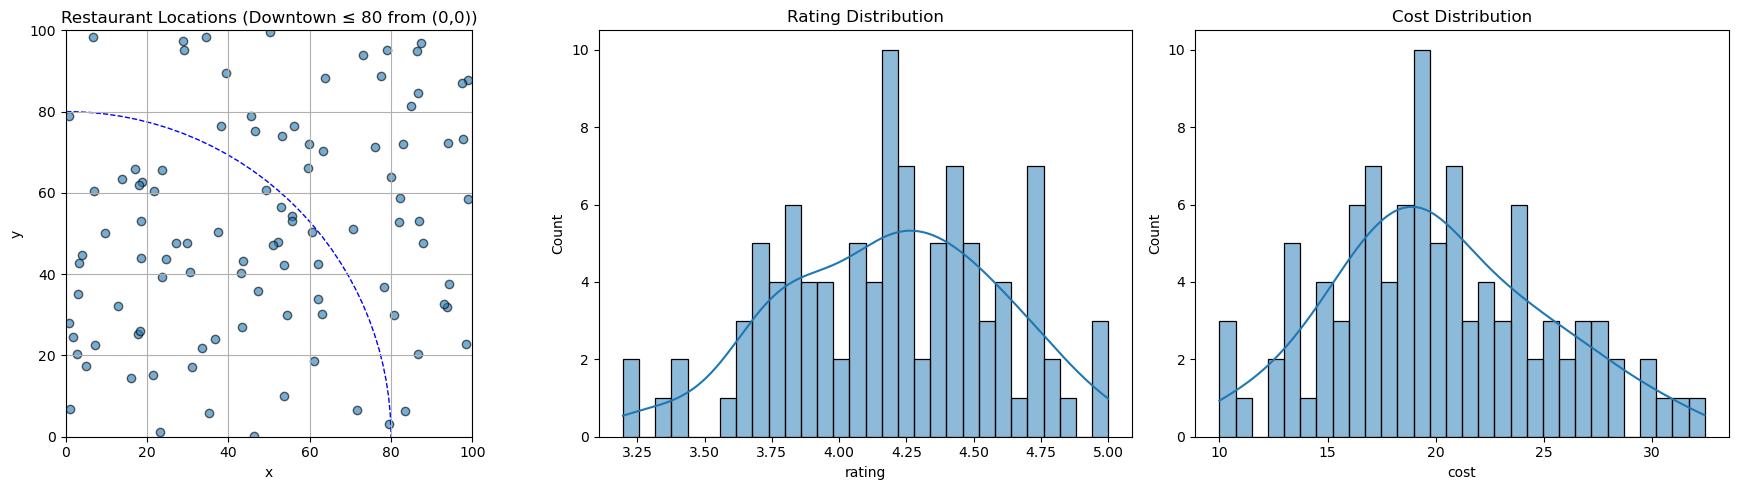

In [4]:
fig = plt.figure(figsize=(18, 5))

# Subplot 1: Restaurant Locations
ax1 = fig.add_subplot(1, 3, 1)
ax1.scatter(df["x"], df["y"], alpha=0.6, edgecolor="black")
ax1.set_title("Restaurant Locations (Downtown ≤ 80 from (0,0))")
# please add a circle with radius 80 around (0,0)
circle = plt.Circle((0, 0), 80, color='blue', fill=False, linestyle='--')
ax1.add_artist(circle)
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_xlim(0, 100)
ax1.set_ylim(0, 100)
ax1.set_aspect('equal', adjustable='box')
ax1.grid(True)

# Subplot 2: Rating Distribution
ax2 = fig.add_subplot(1, 3, 2)
sns.histplot(df["rating"], bins=30, kde=True, ax=ax2)
ax2.set_title("Rating Distribution")

# Subplot 3: Cost Distribution
ax3 = fig.add_subplot(1, 3, 3)
sns.histplot(df["cost"], bins=30, kde=True, ax=ax3)
ax3.set_title("Cost Distribution")

plt.tight_layout()
plt.show()


In [5]:
# df count of cuisines
cuisine_counts = df["cuisine"].value_counts()

print("\nCuisine Counts:")
print(cuisine_counts)


Cuisine Counts:
cuisine
Mexican      16
Ethiopian    16
Lebanese     15
Chinese      12
Korean       12
Japanese     11
Indian       10
French        8
Name: count, dtype: int64


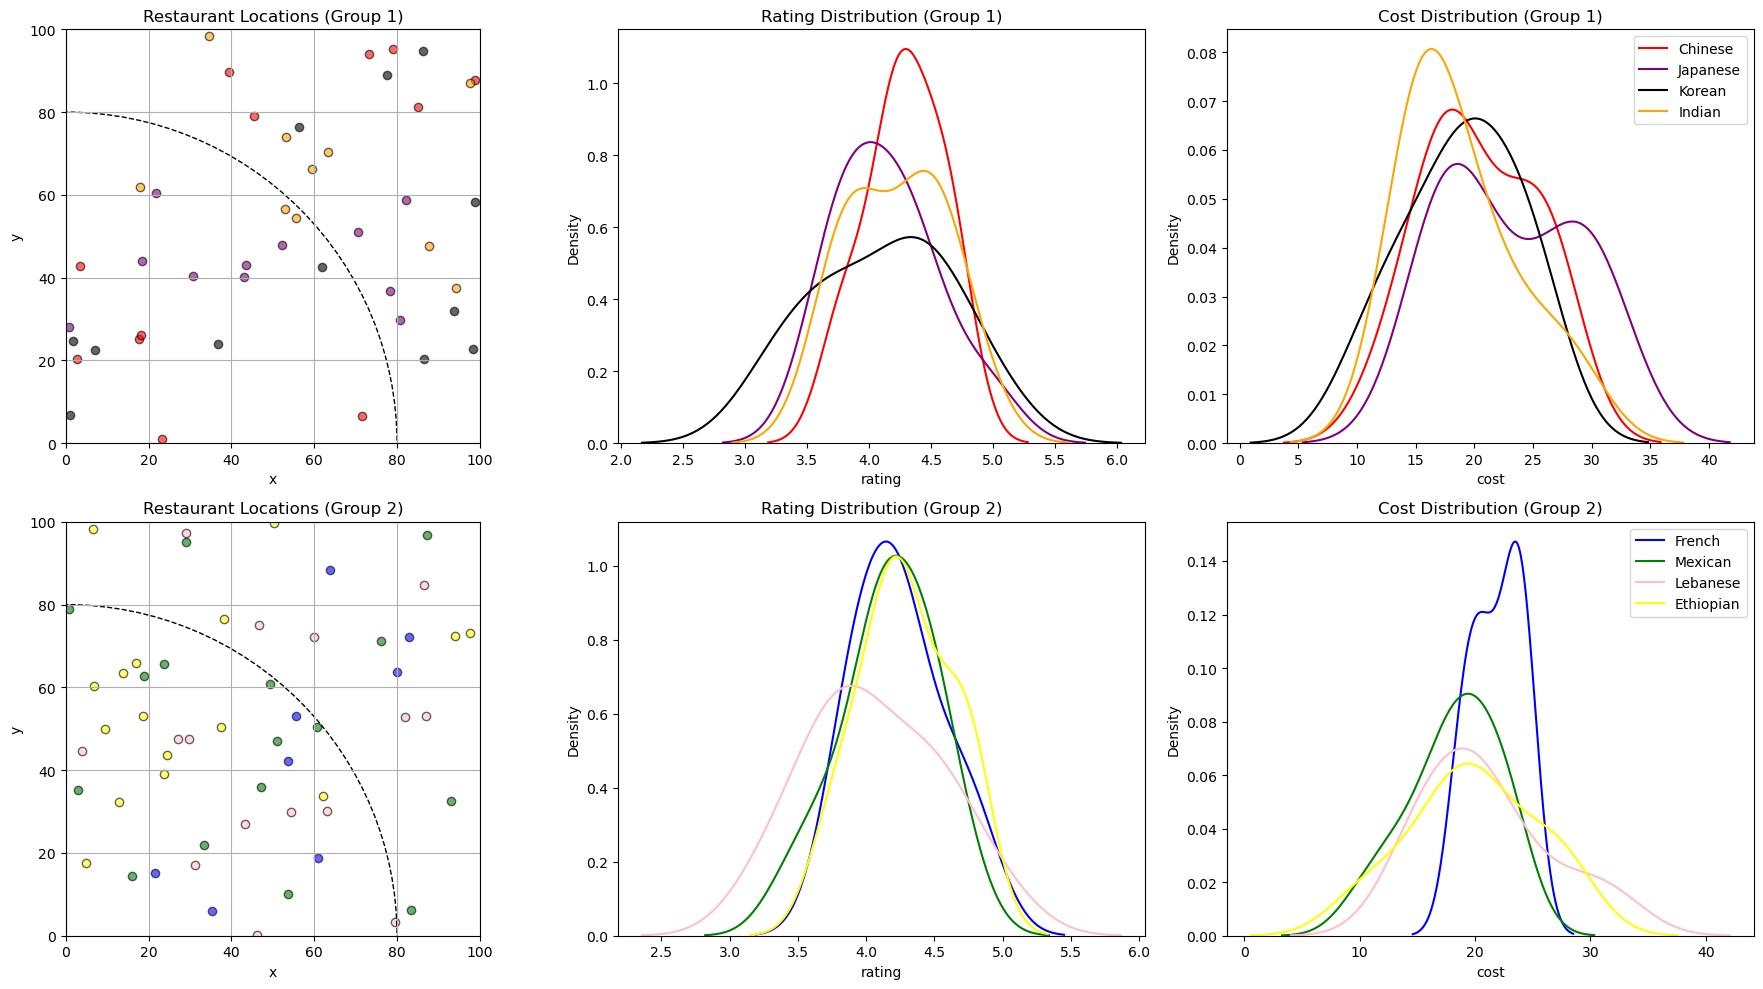

In [6]:
# Define cuisine groups and colors
group1 = ["Chinese", "Japanese", "Korean", "Indian"]
group2 = ["French", "Mexican", "Lebanese", "Ethiopian"]
cuisine_colors = {
    "Chinese": "red",
    "Japanese": "purple",
    "Korean": "black",
    "Indian": "orange",
    "French": "blue",
    "Mexican": "green",
    "Lebanese": "pink",
    "Ethiopian": "yellow"
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=False, sharey=False)

# Plot 1: Restaurant map (group1)
ax = axes[0, 0]
for cuisine in group1:
    subset = df[df["cuisine"] == cuisine]
    ax.scatter(subset["x"], subset["y"], alpha=0.6, label=cuisine, color=cuisine_colors[cuisine], edgecolor="black")
circle = plt.Circle((0, 0), 80, color='black', fill=False, linestyle='--')
ax.add_artist(circle)
ax.set_title("Restaurant Locations (Group 1)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_aspect('equal', adjustable='box')
ax.grid(True)

# Plot 2: Rating (group1)
ax = axes[0, 1]
for cuisine in group1:
    sns.kdeplot(df[df["cuisine"] == cuisine]["rating"], ax=ax, label=cuisine, color=cuisine_colors[cuisine])
ax.set_title("Rating Distribution (Group 1)")

# Plot 3: Cost (group1)
ax = axes[0, 2]
for cuisine in group1:
    sns.kdeplot(df[df["cuisine"] == cuisine]["cost"], ax=ax, label=cuisine, color=cuisine_colors[cuisine])
ax.set_title("Cost Distribution (Group 1)")
ax.legend()

# Plot 4: Restaurant map (group2)
ax = axes[1, 0]
for cuisine in group2:
    subset = df[df["cuisine"] == cuisine]
    ax.scatter(subset["x"], subset["y"], alpha=0.6, label=cuisine, color=cuisine_colors[cuisine], edgecolor="black")
circle = plt.Circle((0, 0), 80, color='black', fill=False, linestyle='--')
ax.add_artist(circle)
ax.set_title("Restaurant Locations (Group 2)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_aspect('equal', adjustable='box')
ax.grid(True)


# Plot 5: Rating (group2)
ax = axes[1, 1]
for cuisine in group2:
    sns.kdeplot(df[df["cuisine"] == cuisine]["rating"], ax=ax, label=cuisine, color=cuisine_colors[cuisine])
ax.set_title("Rating Distribution (Group 2)")


# Plot 6: Cost (group2)
ax = axes[1, 2]
for cuisine in group2:
    sns.kdeplot(df[df["cuisine"] == cuisine]["cost"], ax=ax, label=cuisine, color=cuisine_colors[cuisine])
ax.set_title("Cost Distribution (Group 2)")
ax.legend()

plt.tight_layout()
plt.show()


In [7]:
df
# df.to_csv(f"restaurants{J}.dat", index=False)

,restaurant_id,x,y,rating,cost,cuisine,Chinese,Ethiopian,French,Indian,Japanese,Korean,Lebanese,Mexican
0,0,87.342940,96.854066,4.175700,22.277540,Mexican,False,False,False,False,False,False,False,True
1,1,86.919454,53.085569,3.226207,16.369126,Lebanese,False,False,False,False,False,False,True,False
2,2,23.272833,1.139880,4.067605,17.454146,Chinese,True,False,False,False,False,False,False,False
3,3,43.046882,40.235136,4.389057,16.110933,Japanese,False,False,False,False,True,False,False,False
4,4,52.267467,47.839180,3.845933,27.372180,Japanese,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,79.049190,95.248190,4.265228,27.135584,Chinese,True,False,False,False,False,False,False,False
96,96,28.982083,95.201409,3.422840,16.236062,Mexican,False,False,False,False,False,False,False,True
97,97,18.404427,44.006135,4.591497,30.179836,Japanese,False,False,False,False,True,False,False,False
98,98,18.249948,26.065097,4.653364,18.757552,Chinese,True,False,False,False,False,False,False,False


In [8]:
# Define number of individuals
N = 10000

# Step 1: Generate individual locations
def generate_locations(n):
    locations = []
    while len(locations) < n:
        x = np.random.uniform(0, 100)
        y = np.random.uniform(0, 100)
        locations.append((x, y))
    return np.array(locations)

individual_locations = generate_locations(N)

# Step 2: Save to individual.dat
df_individuals = pd.DataFrame({
    "individual_id": np.arange(N),
    "user_x": individual_locations[:, 0],
    "user_y": individual_locations[:, 1]
})
# df_individuals.to_csv(f"individual{J}.dat", index=False) #no need

In [19]:
df_individuals

,individual_id,user_x,user_y
0,0,5.762889,47.140252
1,1,91.774874,62.432455
2,2,35.125820,84.834566
3,3,10.324690,63.849019
4,4,63.663967,88.814428
...,...,...,...
9995,9995,77.154611,85.326606
9996,9996,43.610684,73.390707
9997,9997,11.641344,15.438759
9998,9998,31.437163,56.278666


## 2. Setting the True Utility Parameters

We define a utility function based on interpretable attributes:

$
U_{nj} = \beta_{\text{log\_dist}} \cdot \log(\text{dist}_{nj}) + \beta_{\text{rate}} \cdot \text{rating}_j + \beta_{\text{cost}} \cdot \text{cost}_j + \sum_k \beta_k^{\text{cuisine}} \cdot \text{cuisine}_{jk} + \varepsilon_{nj}
$

Where:
- $ \text{dist}_{nj}$ is the Euclidean distance between individual \(n\) and restaurant \(j\)
- $ \text{rating}_j$ is the restaurant's average rating
- $ \text{cost}_j$ is the average meal price
- $ \text{cuisine}_{jk}$ is a one-hot encoding of cuisine types

The coefficients ($ \beta $) reflect plausible user behavior, e.g., negative utility from distance and cost, positive utility from rating, and mild preferences for specific cuisines.

We simulate choices by drawing from the multinomial logit model using the true utility values.


In [9]:
SCALE = 1

true_parameters = {
    'beta_rating': 0.75 * SCALE,
    'beta_cost': -0.4 * SCALE,
    'beta_log_dist': -0.60 * SCALE,
    'beta_chinese': 0.75 * SCALE,
    'beta_japanese': 1.25 * SCALE,
    'beta_korean': 0.75 * SCALE,
    'beta_indian': 1 * SCALE,
    'beta_french': 0.75 * SCALE,
    'beta_mexican': 1.25 * SCALE,
    'beta_lebanese': 0.75 * SCALE,
    # 'beta_ethiopian': 0.5 * SCALE, 
}

# Reconstruct cuisine betas from true_parameters
beta_cuisine = {
    "Chinese": true_parameters['beta_chinese'],
    "Japanese": true_parameters['beta_japanese'],
    "Korean": true_parameters['beta_korean'],
    "Indian": true_parameters['beta_indian'],
    "French": true_parameters['beta_french'],
    "Mexican": true_parameters['beta_mexican'],
    "Lebanese": true_parameters['beta_lebanese'],
    # "Ethiopian": true_parameters['beta_ethiopian'] # base and is not included in the model
}

# Store rating, cost, and distance parameters
beta_rate = true_parameters['beta_rating']
beta_cost = true_parameters['beta_cost']
beta_log_dist = true_parameters['beta_log_dist']

true_parameters


{'beta_rating': 0.75,
 'beta_cost': -0.4,
 'beta_log_dist': -0.6,
 'beta_chinese': 0.75,
 'beta_japanese': 1.25,
 'beta_korean': 0.75,
 'beta_indian': 1,
 'beta_french': 0.75,
 'beta_mexican': 1.25,
 'beta_lebanese': 0.75}

In [10]:
df

,restaurant_id,x,y,rating,cost,cuisine,Chinese,Ethiopian,French,Indian,Japanese,Korean,Lebanese,Mexican
0,0,87.342940,96.854066,4.175700,22.277540,Mexican,False,False,False,False,False,False,False,True
1,1,86.919454,53.085569,3.226207,16.369126,Lebanese,False,False,False,False,False,False,True,False
2,2,23.272833,1.139880,4.067605,17.454146,Chinese,True,False,False,False,False,False,False,False
3,3,43.046882,40.235136,4.389057,16.110933,Japanese,False,False,False,False,True,False,False,False
4,4,52.267467,47.839180,3.845933,27.372180,Japanese,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,79.049190,95.248190,4.265228,27.135584,Chinese,True,False,False,False,False,False,False,False
96,96,28.982083,95.201409,3.422840,16.236062,Mexican,False,False,False,False,False,False,False,True
97,97,18.404427,44.006135,4.591497,30.179836,Japanese,False,False,False,False,True,False,False,False
98,98,18.249948,26.065097,4.653364,18.757552,Chinese,True,False,False,False,False,False,False,False


In [11]:
df_individuals

,individual_id,user_x,user_y
0,0,5.762889,47.140252
1,1,91.774874,62.432455
2,2,35.125820,84.834566
3,3,10.324690,63.849019
4,4,63.663967,88.814428
...,...,...,...
9995,9995,77.154611,85.326606
9996,9996,43.610684,73.390707
9997,9997,11.641344,15.438759
9998,9998,31.437163,56.278666


## 3. Simulating Observed Choices

For each of the 10,000 individuals, we:
1. Generate a random home location on the grid.
2. Compute the utility of each of the 500 restaurants.
3. Add Gumbel-distributed noise to simulate the stochastic component of utility.
4. Record the ID of the restaurant with the highest utility.

We save this in `obs_choice.dat`, with columns:
- `user_lat` and `user_lon`: the individual’s coordinates
- `logit_0`: the ID of the chosen restaurant


In [ ]:
# Initialize choice array
choices = []

for i in range(N):
    user_x, user_y = individual_locations[i]
    dists = np.sqrt((df['x'] - user_x) ** 2 + (df['y'] - user_y) ** 2)

    # Compute systematic utility
    V = (
        beta_rate * df["rating"].values +
        beta_cost * df["cost"].values +
        beta_log_dist * np.log(dists) +
        sum(beta_cuisine[c] * df[c].values for c in beta_cuisine)
    )

    # Compute choice probabilities using softmax
    V = V - np.max(V)  # for numerical stability
    exp_V = np.exp(V)
    probs = exp_V / exp_V.sum()    # Compute choice probabilities using softmax
    V = V - np.max(V)  # for numerical stability
    exp_V = np.exp(V)
    probs = exp_V / exp_V.sum()
    

    # Draw one alternative according to logit probabilities
    # It should be a random choice according to the probabilities
    chosen_idx = np.random.choice(len(df), p=probs)
    choices.append((i, df.loc[chosen_idx, "restaurant_id"]))


0    -4.989588
1    -3.742086
2    -3.243395
3    -1.808494
4    -6.842878
        ...   
95   -7.314087
96   -2.788370
97   -6.643057
98   -2.906778
99   -1.502628
Length: 100, dtype: float64
shape of exp V (100,)
0    -4.709625
1    -2.842931
2    -3.945747
3    -2.343142
4    -7.110927
        ...   
95   -7.094126
96   -3.285696
97   -8.026214
98   -3.959470
99   -2.701196
Length: 100, dtype: float64
shape of exp V (100,)
0    -4.937103
1    -3.861184
2    -3.862345
3    -2.209658
4    -7.058372
        ...   
95   -7.210314
96   -2.189891
97   -7.669586
98   -3.750069
99   -2.458326
Length: 100, dtype: float64
shape of exp V (100,)
0    -5.003318
1    -3.804052
2    -3.493657
3    -1.938252
4    -6.914084
        ...   
95   -7.317323
96   -2.652490
97   -7.034114
98   -3.272118
99   -1.932716
Length: 100, dtype: float64
shape of exp V (100,)
0    -4.408669
1    -3.577483
2    -3.870818
3    -2.230127
4    -7.012501
        ...   
95   -6.541649
96   -2.762975
97   -7.818657
98   

In [13]:
df_choices = pd.DataFrame(choices, columns=["individual_id", "restaurant_id"])

# Add the chosen restaurant's cuisine
df_choices["cuisine"] = df_choices["restaurant_id"].map(df.set_index("restaurant_id")["cuisine"])

# Count how many times each restaurant was chosen
restaurant_choice_counts = df_choices["restaurant_id"].value_counts().sort_index()

# Map to the full restaurant DataFrame
df["times_chosen"] = df["restaurant_id"].map(restaurant_choice_counts).fillna(0).astype(int)

# Summary statistics
summary = {
    "most_chosen_restaurant_id": int(df["times_chosen"].idxmax()),
    "most_chosen_count": int(df["times_chosen"].max()),
    "least_chosen_restaurant_id": int(df["times_chosen"].idxmin()),
    "least_chosen_count": int(df["times_chosen"].min()),
    "number_of_restaurants_never_chosen": int((df["times_chosen"] == 0).sum()),
    "average_times_chosen": float(df["times_chosen"].mean()),
    "std_dev_times_chosen": float(df["times_chosen"].std())
}

# Cuisine-level statistics
cuisine_choice_counts = df_choices["cuisine"].value_counts().sort_values(ascending=False)

summary, cuisine_choice_counts


({'most_chosen_restaurant_id': 42,
  'most_chosen_count': 1475,
  'least_chosen_restaurant_id': 11,
  'least_chosen_count': 0,
  'number_of_restaurants_never_chosen': 8,
  'average_times_chosen': 100.0,
  'std_dev_times_chosen': 200.51166872012536},
 cuisine
 Mexican      3343
 Ethiopian    1538
 Korean       1388
 Chinese      1106
 Indian       1068
 Lebanese      810
 Japanese      610
 French        137
 Name: count, dtype: int64)

In [14]:
# Rename and prepare final obs_choice DataFrame with requested columns
df_obs_choice = df_choices.copy()
df_obs_choice["user_y"] = df_individuals.loc[df_obs_choice["individual_id"], "user_y"].values
df_obs_choice["user_x"] = df_individuals.loc[df_obs_choice["individual_id"], "user_x"].values
df_obs_choice["logit_0"] = df_obs_choice["restaurant_id"]

# Keep only required columns
df_obs_choice_final = df_obs_choice[["user_y", "user_x", "logit_0"]]
# df_obs_choice_final.to_csv(f'obs_choice{J}.dat', index=False)

In [15]:
df_obs_choice

,individual_id,restaurant_id,cuisine,user_y,user_x,logit_0
0,0,12,Korean,47.140252,5.762889,12
1,1,73,Japanese,62.432455,91.774874,73
2,2,42,Mexican,84.834566,35.125820,42
3,3,22,Chinese,63.849019,10.324690,22
4,4,78,Indian,88.814428,63.663967,78
...,...,...,...,...,...,...
9995,9995,39,French,85.326606,77.154611,39
9996,9996,31,Mexican,73.390707,43.610684,31
9997,9997,12,Korean,15.438759,11.641344,12
9998,9998,79,Mexican,56.278666,31.437163,79


Text(0, 0.5, 'Frequency')

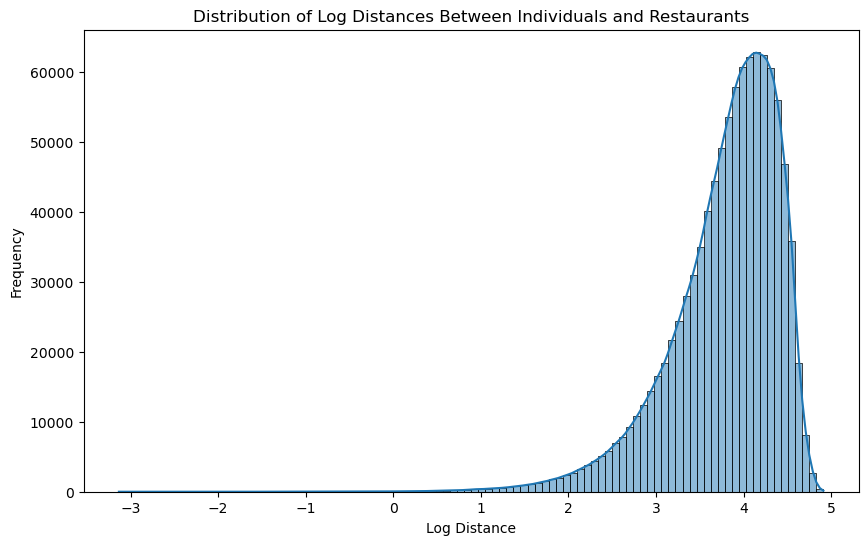

In [18]:
# plot distribution of log_distances between individuals and restaurants
distances = np.sqrt((df['x'].values - df_individuals['user_x'].values[:, None]) ** 2 + 
                    (df['y'].values - df_individuals['user_y'].values[:, None]) ** 2)
log_distances = np.log(distances)
plt.figure(figsize=(10, 6))
sns.histplot(log_distances.flatten(), bins=100, kde=True)
plt.title("Distribution of Log Distances Between Individuals and Restaurants")
plt.xlabel("Log Distance")
plt.ylabel("Frequency") 